In [1]:
import pyodbc
import pandas as pd
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

First get all useful values from the database

In [2]:
CONNECTION_STRING = "DRIVER={ODBC Driver 17 for SQL Server};SERVER=MIKELE;DATABASE=CRH;UID=MIKELE\Mikel;Trusted_Connection=yes"

channel = pyodbc.connect(CONNECTION_STRING)
cursor = channel.cursor()
sql = '''SELECT c.ID AS CandID, c.InstanceID,	c.Gender, c.Genderchoice, c.Qualification, fca.TestStartTime, fca.TestFinishTime, fca.Data
FROM CRH.dbo.Candidate c JOIN CRH.dbo.CandidateResultFCA fca
ON c.ID = fca.CandidateID AND c.InstanceID = fca.InstanceID'''
df = pd.read_sql(sql, channel)
df.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Mikel\AppData\Local\Temp\ipykernel_11416\2033935806.py:1: SyntaxWarning: invalid escape sequence '\M'
  CONNECTION_STRING = "DRIVER={ODBC Driver 17 for SQL Server};SERVER=MIKELE;DATABASE=CRH;UID=MIKELE\Mikel;Trusted_Connection=yes"
C:\Users\Mikel\AppData\Local\Temp\ipykernel_11416\2033935806.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, channel)


,CandID,InstanceID,Gender,Genderchoice,Qualification,TestStartTime,TestFinishTime,Data
0,290047,3,Gender_Female,Gender_Female,Qualification_Bachelor,2020-09-03 17:31:21.543,2020-09-03 17:59:08.157,b'\x00\r\xc2\x9b\xa8\x0ep\x80\xb5\xa0\x00\x00\...
1,290183,3,Gender_Male,Gender_Male,Qualification_Bachelor,2020-09-02 19:47:01.153,2020-09-02 20:24:36.110,b'\x00\r\xc2\x9dL\x0ep\x80\xb5\xa0\x00\x00\x00...
2,290190,3,Gender_Female,Gender_Female,Qualification_Vocational,2020-09-04 12:41:08.317,2020-09-04 13:29:33.347,b'\x00\r\xc2\x9c\xa8\x0ep\x80\xb5\xa0\x00\x00\...
3,290192,3,Gender_Female,Gender_Female,Qualification_Bachelor,2020-09-06 16:51:44.317,2020-09-06 17:29:59.540,b'\x00\r\xc2\x9a\xac\x0ep\x80\xb5\xa0\x00\x00\...
4,291119,3,Gender_Male,Gender_Male,Qualification_PostGraduate,2020-09-13 16:01:28.103,2020-09-13 16:37:21.160,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...


One hot encode the categorical columns

In [3]:
from sklearn.preprocessing import OneHotEncoder
cat_fca = df[['Gender','Genderchoice','Qualification']]
enc = OneHotEncoder(sparse_output=False)
enc.fit(cat_fca)
cat_fca = enc.transform(cat_fca)
cat_fca = pd.DataFrame(cat_fca,columns=enc.get_feature_names_out(), dtype='int')
cat_fca[:5]

,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Genderchoice_Gender_Female,Genderchoice_Gender_Male,Genderchoice_Gender_Other,Genderchoice_Gender_Unknown,Genderchoice_None,Qualification_,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0


Create a duration column (total time in seconds) and scale it

In [4]:
df['Duration'] = (df.TestFinishTime - df.TestStartTime).dt.total_seconds().astype(int)
df[:2]

,CandID,InstanceID,Gender,Genderchoice,Qualification,TestStartTime,TestFinishTime,Data,Duration
0,290047,3,Gender_Female,Gender_Female,Qualification_Bachelor,2020-09-03 17:31:21.543,2020-09-03 17:59:08.157,b'\x00\r\xc2\x9b\xa8\x0ep\x80\xb5\xa0\x00\x00\...,1666
1,290183,3,Gender_Male,Gender_Male,Qualification_Bachelor,2020-09-02 19:47:01.153,2020-09-02 20:24:36.110,b'\x00\r\xc2\x9dL\x0ep\x80\xb5\xa0\x00\x00\x00...,2254


In [5]:
df_processed = pd.concat([df[['CandID','InstanceID','Data','Duration']],cat_fca],axis=1)
df_processed.head(5)

,CandID,InstanceID,Data,Duration,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Genderchoice_Gender_Female,Genderchoice_Gender_Male,Genderchoice_Gender_Other,...,Qualification_,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
0,290047,3,b'\x00\r\xc2\x9b\xa8\x0ep\x80\xb5\xa0\x00\x00\...,1666,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
1,290183,3,b'\x00\r\xc2\x9dL\x0ep\x80\xb5\xa0\x00\x00\x00...,2254,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,290190,3,b'\x00\r\xc2\x9c\xa8\x0ep\x80\xb5\xa0\x00\x00\...,2905,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,290192,3,b'\x00\r\xc2\x9a\xac\x0ep\x80\xb5\xa0\x00\x00\...,2295,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
4,291119,3,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,2153,0,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [6]:
len(df_processed['Data'].iloc[0])

800

In [7]:
sc = sk.preprocessing.StandardScaler()
df_processed.Duration = sc.fit_transform(df[['Duration']])


In [8]:
df_processed.head()

,CandID,InstanceID,Data,Duration,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Genderchoice_Gender_Female,Genderchoice_Gender_Male,Genderchoice_Gender_Other,...,Qualification_,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
0,290047,3,b'\x00\r\xc2\x9b\xa8\x0ep\x80\xb5\xa0\x00\x00\...,-0.012288,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
1,290183,3,b'\x00\r\xc2\x9dL\x0ep\x80\xb5\xa0\x00\x00\x00...,-0.010672,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,290190,3,b'\x00\r\xc2\x9c\xa8\x0ep\x80\xb5\xa0\x00\x00\...,-0.008882,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,290192,3,b'\x00\r\xc2\x9a\xac\x0ep\x80\xb5\xa0\x00\x00\...,-0.010559,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
4,291119,3,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,-0.010949,0,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


Plot the values to check for discrepancies

<Axes: ylabel='Count'>

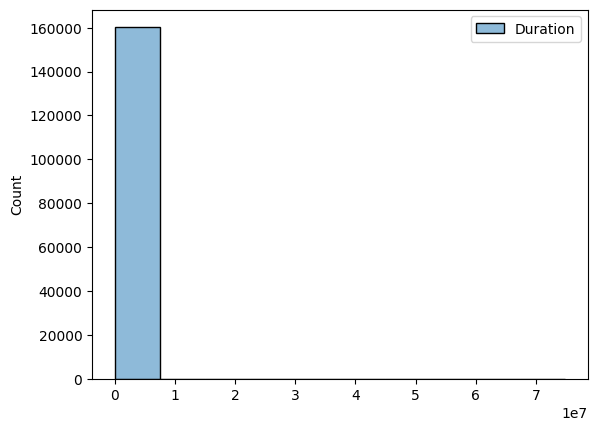

In [9]:
sns.histplot(df[['Duration']], bins=10)

It seems that there are some outliers, let's check in depth
I think the max time is 3600s

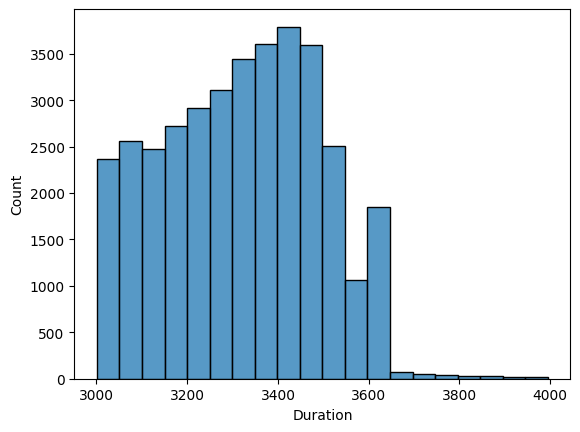

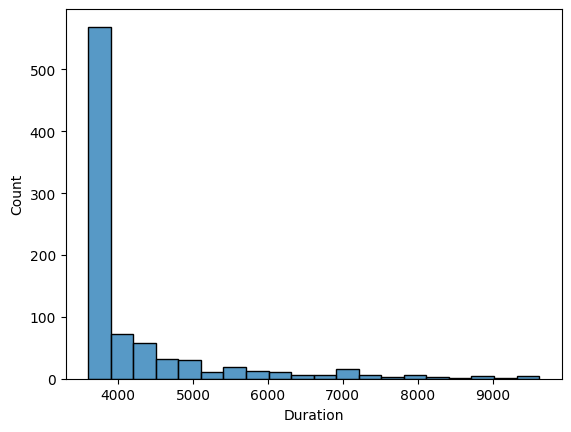

In [10]:
sns.histplot(df.Duration[(df.Duration > 3000) & (df.Duration < 4000)],bins=20)
plt.show()
sns.histplot(df.Duration[(df.Duration > 3600) & (df.Duration < 10000)],bins=20)
plt.show()

It seems that there is not an exceptional amount of tests completed in 3600, but it does drop significantly\
I assume these values are good, so I leave them be\

The next step is to start training models. Sklearn provides a list of unsupervised clustering models:
[Sklearn Clustering](https://scikit-learn.org/dev/modules/clustering.html#clustering)

I first have to split the data into a training, validation and test set

In [11]:
from sklearn.model_selection import train_test_split

df_processed_train_full, df_processed_test = train_test_split(df_processed)
df_processed_train = df_processed_train_full[:-10000] 
df_processed_valid = df_processed_train_full[-10000:] 
print(len(df_processed_train),len(df_processed_valid),len(df_processed_test))


110163 10000 40055


## K-means

For K-Means to work, it seems that I need to convert the bytestrings. I'll try converting them to bitstrings first

In [12]:
string = df_processed.Data.iloc[0]

In [13]:
bit_strings = [list(format(byte, '08b')) for byte in string]
data = np.array(bit_strings)
data[0]

array(['0', '0', '0', '0', '0', '0', '0', '0'], dtype='<U1')

In [14]:
bits = ''.join(format(byte, '08b') for byte in string)
bits

'000000000000110111000010100110111010100000001110011100001000000010110101101000000000000000000000000000000000000000000000011001110000000000001101110100101001101010010100000001010111000100000000000000000000000000000000000000000000000000000000000000000001101100000000000011011110001010011011100101000000010101110101000000000000000000000000000000000000000000000000000000000000000000100010000000000000110111110010100111000111010000000101001100101000000001101110101000000000000000000000000000000000000000000000110111100000000000001110000000101001101110010100000011100011001010000001111011101010000000000000000000000000000000000000000010011010100000000000000011100001001010011011101100000000111010001010100000000000000000000000000000000000000000000000000000000000000010010000000000000000111000100010100111001010110000001111101100010000000001101110101000000000000000000000000000000000000000000000101010110000000000001110001100101001110100110000000000111000101010000000000000000000000000000000000000000000000

In [15]:
df_processed_vect = df_processed
df_processed_vect['Data'] = df_processed_vect['Data'].apply(lambda x: ''.join(format(byte, '08b') for byte in x))
df_processed_vect.head()


,CandID,InstanceID,Data,Duration,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Genderchoice_Gender_Female,Genderchoice_Gender_Male,Genderchoice_Gender_Other,...,Qualification_,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
0,290047,3,0000000000001101110000101001101110101000000011...,-0.012288,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
1,290183,3,0000000000001101110000101001110101001100000011...,-0.010672,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,290190,3,0000000000001101110000101001110010101000000011...,-0.008882,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,290192,3,0000000000001101110000101001101010101100000011...,-0.010559,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
4,291119,3,0000000000000000000000000000000000000000000000...,-0.010949,0,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [16]:
df_processed_train_full_kmeans, df_processed_test_kmeans = train_test_split(df_processed_vect)
df_processed_train_kmeans = df_processed_train_full_kmeans[:-10000] 
df_processed_valid_kmeans = df_processed_train_full_kmeans[-10000:]

I get an error when using the datafields as input for kmeans.\
I go on without the data field to experiment

In [17]:
from sklearn.cluster import KMeans

df_processed_train_full_kmeans_no_data = df_processed_train_full_kmeans.drop(['Data'],axis=1)
km = KMeans()
km.fit(df_processed_train_full_kmeans_no_data)

KMeans()

In [18]:
km.feature_names_in_

array(['CandID', 'InstanceID', 'Duration', 'Gender_Gender_Female',
       'Gender_Gender_Male', 'Gender_Gender_Unknown',
       'Genderchoice_Gender_Female', 'Genderchoice_Gender_Male',
       'Genderchoice_Gender_Other', 'Genderchoice_Gender_Unknown',
       'Genderchoice_None', 'Qualification_',
       'Qualification_Qualification_Bachelor',
       'Qualification_Qualification_MBA',
       'Qualification_Qualification_Master',
       'Qualification_Qualification_PHD',
       'Qualification_Qualification_PostGraduate',
       'Qualification_Qualification_Professional',
       'Qualification_Qualification_Secondary',
       'Qualification_Qualification_Unknown',
       'Qualification_Qualification_Vocational'], dtype=object)

In [19]:
km.get_feature_names_out()
km.inertia_

1032439572845711.6

These results are not very promising..\
Maybe I should try to split the bytestring into chunks of 16B and expand the Data-field to 40 fields (1 per test item (=question))

In [20]:
df_processed_train_full_kmeans.Data.head()

41251     0000000000001101110000101001110000110100000011...
131885    0000000000001101110000101001101110101000000011...
45156     0000000000011001011100101001110101010000000011...
25880     0000000000001101110000101001110110001100000011...
82809     0000000000011001011100101001110100101100000010...
Name: Data, dtype: object

In [21]:
df_data_substr = df_processed_train_full_kmeans['Data'].str[:128].apply(lambda x: int(x,2))
df_processed_train_full_kmeans_int = pd.DataFrame(df_data_substr,index=df_data_substr.index).join(df_processed_train_full_kmeans_no_data)
df_processed_train_full_kmeans_int.head()

,Data,CandID,InstanceID,Duration,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Genderchoice_Gender_Female,Genderchoice_Gender_Male,Genderchoice_Gender_Other,...,Qualification_,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
41251,71447022328090159971138546245304406,3851896,1,-0.011925,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
131885,71446979000188784982828924775956545,4368622,1,-0.007631,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
45156,132132079754752169417754528440123460,3740666,1,-0.011323,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
25880,71447128790933538513842187569987644,3636908,1,-0.010342,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
82809,132132068609502116746829164064014485,4281588,1,-0.012098,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


In [22]:
km.fit(df_processed_train_full_kmeans_int)

KMeans()

In [23]:
km.inertia_

2.7223680854141267e+70

This creates an even bigger inertia, so that's not good..\
Let's try the same method without one hot encoding

In [24]:
km.fit(df_processed_train_full_kmeans_int[['Data','CandID','InstanceID','Duration']])

KMeans()

In [25]:
km.inertia_

2.722368085414129e+70

In [26]:
km.fit(df_processed_train_full_kmeans_int[['Data']])

KMeans()

In [27]:
km.inertia_

2.7223680854143097e+70

No good..\
Maybe I should try PCA?\
First I'm going to try splitting the bitstrings into chunks of 128 bits
I remove the first 20 bits because this represents the item number and this is represented by the column name

In [28]:
df_itemsplit = df_processed_train[['CandID','Data']]

bits_per_item = 128
df_itemsplit['Data'] = df_itemsplit['Data'].apply(lambda x: ''.join(format(byte, '08b') for byte in x))

n_of_items = len(df_itemsplit['Data'].iloc[0])//bits_per_item

for i in range(n_of_items):
    start = (i * bits_per_item) + 20
    end = start + bits_per_item -20
    df_itemsplit[f'item_{i+1}'] = df_itemsplit['Data'].str[start:end]

df_itemsplit = df_itemsplit.drop(columns=['Data','CandID'])
df_itemsplit
# km.fit(df_itemsplit)

C:\Users\Mikel\AppData\Local\Temp\ipykernel_11416\2391302317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itemsplit['Data'] = df_itemsplit['Data'].apply(lambda x: ''.join(format(byte, '08b') for byte in x))
C:\Users\Mikel\AppData\Local\Temp\ipykernel_11416\2391302317.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itemsplit[f'item_{i+1}'] = df_itemsplit['Data'].str[start:end]
C:\Users\Mikel\AppData\Local\Temp\ipykernel_11416\2391302317.py:11: SettingWithCopyWarning: 
A value is trying to b

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,...,item_41,item_42,item_43,item_44,item_45,item_46,item_47,item_48,item_49,item_50
7649,0010100111010101000000001100101011001000000000...,0010100111001010010000001101010100011000000000...,0010100111010111000000001011010001100000000110...,0010100111010110100000001011100011001000000110...,0010100111010010100000001100010011101000000000...,0010100111000101010000001010010100011000000101...,0010100110111011000000001010101011100000000000...,0010100110010111000000001011100011010000000110...,0010100111000100110000001010011001100000000110...,0010100110111011000000001010010100011000000000...,...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...
124098,0010100111011000100000001110011100001000000010...,0010100110010111000000000101011100010000000000...,0010100110111011000000000101011101010000000000...,0010100110111001010000000101001100101000000001...,0010100110101001010000001110001100101000000111...,0010100111000100110000001110100010101000000000...,0010100110111000100000001111101100010000000001...,0010100111010111000000000011100010101000000000...,0010100110101001010000000100001101011000000111...,0010100110110101010000000011010101011000000000...,...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...
149346,0010100111001010100000001110011100001000000010...,0010100111010100110000000101011100010000000000...,0010100110011001010000000101011101010000000000...,0010100111000100010000000101001100101000000001...,0010100110111011000000001110001100101000000111...,0010100111000101010000001110100010101000000000...,0010100110101011000000001111101100010000000001...,0010100111010011000000000011100010101000000000...,0010100111001010110000000100001101011000000111...,0010100111001010100000000011010101011000000000...,...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...
122829,0010100110011001010000001010010011101000000000...,0010100110111001010000001010010101001000000000...,0010100111010100010000001010001010101000000000...,0010100110111001010000001010010101001000000000...,0010100111010111000000001010101100010000000000...,0010100110101001010000001010001010101000000000...,0010100110111011000000001010001101010000000000...,0010100110111001010000001010001101011000000000...,0010100111000011010000001011101011001000000000...,0010100111010111000000001011011001101000000000...,...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,0000000000000000000000000000000000000000000000...,00

Note that the digits that represent the sequenceId's are the same everywhere. If this is not a coincidence, I should remove or separate them

In [29]:
km.fit(df_itemsplit)

KMeans()

In [30]:
km.inertia_

3.8303309204975747e+214

To try plotting the records in a 2D plot, first normalize the fields and project them to 2 dimensions

In [31]:
df_itemsplit_normalized = pd.DataFrame(sc.fit_transform(df_itemsplit))
df_itemsplit_normalized.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.11751,0.35153,0.241332,0.071284,0.078402,0.070965,0.085204,0.174351,0.127994,0.309041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.11751,0.35153,0.241331,0.071283,0.078400,0.070965,0.085204,0.174352,0.127993,0.309041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.11751,0.35153,0.241331,0.071284,0.078400,0.070965,0.085204,0.174352,0.127994,0.309041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.11751,0.35153,0.241332,0.071283,0.078402,0.070964,0.085204,0.174352,0.127994,0.309041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.11751,0.35153,0.241331,0.071284,0.078400,0.070965,0.085205,0.174352,0.127994,0.309041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
df_itemsplit_normalized = df_itemsplit_normalized.drop(df_itemsplit_normalized.columns[np.arange(22,50)],axis=1)

In [33]:
df_itemsplit_normalized.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,0.11751,0.35153,0.241332,0.071284,0.078402,0.070965,0.085204,0.174351,0.127994,0.309041,...,0.099083,0.197655,0.313462,0.194033,0.683818,0.736773,-1.254481,-1.204782,-1.061209,-1.029024
1,0.11751,0.35153,0.241331,0.071283,0.078400,0.070965,0.085204,0.174352,0.127993,0.309041,...,0.099083,0.197655,0.313462,0.194032,0.683818,0.736773,0.797143,0.830026,0.942321,0.971795
2,0.11751,0.35153,0.241331,0.071284,0.078400,0.070965,0.085204,0.174352,0.127994,0.309041,...,0.099083,0.197656,0.313462,0.194033,0.683818,0.736773,0.797143,0.830026,0.942321,0.971794
3,0.11751,0.35153,0.241332,0.071283,0.078402,0.070964,0.085204,0.174352,0.127994,0.309041,...,0.099083,0.197656,-3.190181,0.194033,-1.462377,-1.357270,-1.254481,-1.204782,-1.061209,-1.029024
4,0.11751,0.35153,0.241331,0.071284,0.078400,0.070965,0.085205,0.174352,0.127994,0.309041,...,0.099083,0.197656,0.313462,0.194032,0.683818,0.736773,0.797143,0.830026,0.942321,0.971794


In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
km_in_train_pca = pca.fit_transform(df_itemsplit_normalized)


In [35]:
km_in_train_pca[0:10]

array([[ 0.38159831, -1.29298208],
       [-1.95836857,  0.7681784 ],
       [-1.95836896,  0.76817768],
       [ 2.62166356, -1.85732345],
       [-1.95836915,  0.76817738],
       [ 4.09340787, -1.11173841],
       [ 1.66194944, -2.288647  ],
       [ 8.14592036,  2.24348515],
       [-1.95836883,  0.76817786],
       [-0.83996694, -0.29366477]])

In [36]:
df_km_pca2 = pd.DataFrame(km_in_train_pca,columns=['x','y'])
df_km_pca2.head()

,x,y
0,0.381598,-1.292982
1,-1.958369,0.768178
2,-1.958369,0.768178
3,2.621664,-1.857323
4,-1.958369,0.768177


<Axes: xlabel='x', ylabel='y'>

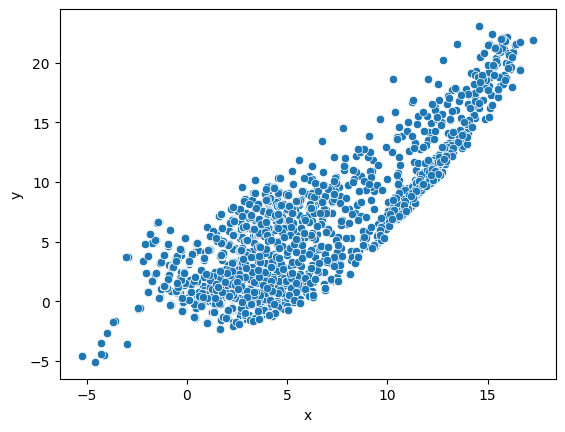

In [37]:
sns.scatterplot(df_km_pca2,x=df_km_pca2.x,y=df_km_pca2.y)

There are 2 ellipsoidal blobs, kmeans is not a good model to cluster these

In [38]:
km_2 = KMeans(2)
km_2.fit(df_km_pca2)
km_2.labels_, km_2.cluster_centers_, km_2.inertia_

(array([1, 0, 0, ..., 0, 0, 1]),
 array([[-1.63761797,  0.70416804],
        [ 2.73763749, -1.17717127]]),
 573357.2822674968)

In [39]:
df_km_pca2[km_2.labels_ == 0]

,x,y
1,-1.958369,0.768178
2,-1.958369,0.768178
4,-1.958369,0.768177
8,-1.958369,0.768178
9,-0.839967,-0.293665
...,...,...
110157,1.077305,4.319360
110158,-0.839967,-0.293665
110159,-0.238894,-0.847313
110160,-1.958369,0.768178


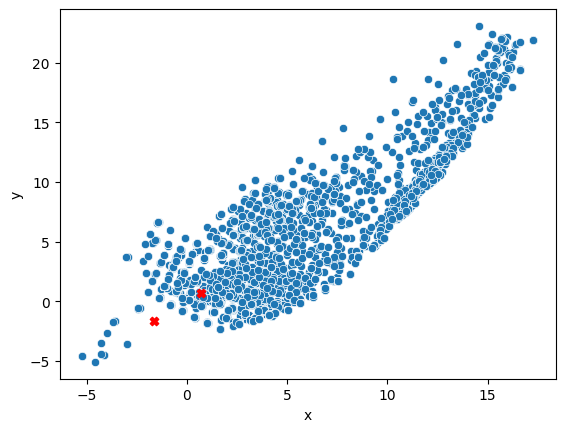

In [40]:
sns.scatterplot(df_km_pca2,x=df_km_pca2.x,y=df_km_pca2.y)
plt.scatter(km_2.cluster_centers_[0],km_2.cluster_centers_[0],color="red", marker="X")
plt.show()

This is the result of looking for 2 clusters. Maybe it's a better idea to get 1 cluster and filter the 1% of instances that are furthest from te cluster center.

In [41]:
km_1 = KMeans(1)
km_1.fit(df_km_pca2)
distances = np.linalg.norm(df_km_pca2 - km_1.cluster_centers_, axis=1)
distances

array([1.34811718, 2.10364101, 2.10364112, ..., 2.10364102, 5.30121236,
       5.67179943])

In [42]:
km_1.cluster_centers_[0][0]

-9.441073041482572e-18

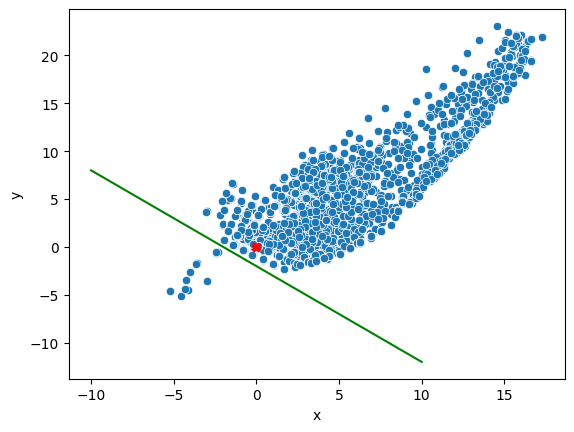

In [46]:
sns.scatterplot(df_km_pca2,x=df_km_pca2.x,y=df_km_pca2.y)
plt.scatter(km_1.cluster_centers_[0][0],km_1.cluster_centers_[0][1],color="red", marker="X")
x = np.linspace(-10, 10, 100)
y = -x
plt.plot(x, y - 2, label='y = -x', color = 'green')
plt.show()

I filter out the points that are visible (note that this is a bad way of filtering results, this is just to check the details of the instances in the hope that I can notice what makes these instances stand out)

In [52]:
left_of_line = df_km_pca2[(df_km_pca2.y < -df_km_pca2.x - 2)]
visual_anomalies = df.iloc[left_of_line.index]
visual_anomalies

,CandID,InstanceID,Gender,Genderchoice,Qualification,TestStartTime,TestFinishTime,Data,Duration
6744,3109478,1,Gender_Male,Gender_Male,Qualification_Unknown,2015-09-14 07:29:45.853,2015-09-14 08:05:02.163,b'\x00\x19r\x9bT\x0c\xac\x80\x00\x00\x00\x00\x...,2116
6838,2842061,1,Gender_Male,Gender_Male,Qualification_Unknown,2013-12-08 01:15:14.110,2013-12-08 02:15:14.110,b'\x00\r\xc2\x9ct\x05\xad\x01\xce\x10\x00\x00\...,3600
10102,3132984,1,Gender_Female,Gender_Female,Qualification_Unknown,2015-10-28 08:15:19.523,2015-10-28 08:54:37.520,b'\x00\x19r\x9cT\nV\x00\x00\x00\x00\x00\x00\x0...,2357
13661,3334087,1,Gender_Unknown,None,Qualification_Unknown,2017-01-03 12:24:48.467,2017-01-03 12:59:23.807,b'\x00\x19r\x9ct\x1d5\x83\xedP\x00\x00\x00\x00...,2075
19034,3456005,1,Gender_Male,Gender_Male,Qualification_Master,2017-08-23 13:05:24.093,2017-08-23 14:06:27.043,b'\x00\x19r\x9b\x94\x1d5\x83\xedP\x00\x00\x00\...,3662
19075,3418253,1,Gender_Female,Gender_Female,Qualification_Unknown,2017-05-26 12:19:44.527,2017-05-26 12:58:25.427,b'\x00\r\xc2\x9c\xa8\x0ep\x80\xb5\xa0\x00\x00\...,2320
29893,3637268,1,Gender_Female,Gender_Female,Qualification_Bachelor,2018-06-03 08:47:34.927,2018-06-03 09:31:47.020,b'\x00\r\xc2\x9ch\x0ep\x80\xb5\xa0\x00\x00\x00...,2652
38749,3792968,1,Gender_Female,Gender_Female,Qualification_Unknown,2018-12-12 08:24:20.027,2018-12-12 08:55:11.280,b'\x00\x19r\x99\x94\np\x80\x00\x00\x00\x00\x00...,1851
46838,3787900,1,Gender_Female,Gender_Female,Qualification_Unknown,2018-12-05 08:30:12.953,2018-12-05 08:54:32.970,b'\x00\x19r\x99P\np\x80\x00\x00\x00\x00\x00\x0...,1460
46878,3862358,5,Gender_Male,Gender_Male,Qualification_Unknown,2019-04-06 00:23:09.697,2019-04-06 01:11:59.880,b'\x00\r\xc2\x9b\xa4\x0ep\x80\xb5\xa0\x00\x00\...,2930


In [ ]:

visual_anomalies.to_csv('./pca_2_visual_anomalies.csv', index=False)

<Axes: ylabel='Count'>

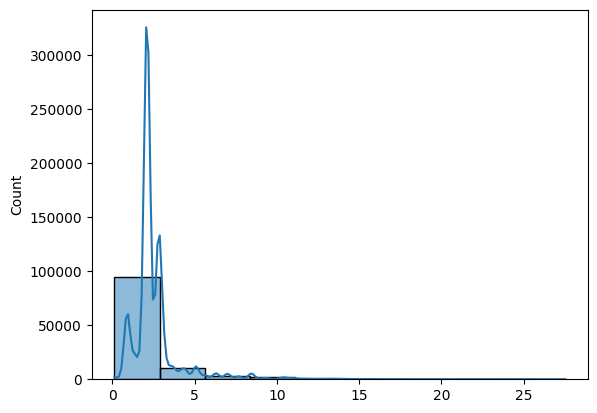

In [ ]:
sns.histplot(distances,bins=10, kde=True)

In [ ]:
len(distances[distances > 10])

1563

In [ ]:
indices = np.where(distances>10)
indices

(array([   129,    251,    288, ..., 109687, 109982, 110003], dtype=int64),)

In [ ]:
anomalies = df.iloc[indices]
anomalies.head()

,CandID,InstanceID,Gender,Genderchoice,Qualification,TestStartTime,TestFinishTime,Data,Duration
129,2010,4,Gender_Female,Gender_Female,Qualification_Master,2024-01-15 17:39:27.453,2024-01-15 18:25:35.433,b'\x00\x19r\x9ct\x1d5\x83\xedP\x00\x00\x00\x00...,2767
251,4115,4,Gender_Male,Gender_Male,Qualification_Unknown,2024-05-24 14:47:34.553,2024-05-24 15:45:37.173,b'\x00\x19r\x9a\x94\x1d5\x83\xedP\x00\x00\x00\...,3482
288,4040,4,Gender_Male,Gender_Male,Qualification_Unknown,2024-05-04 14:58:43.233,2024-05-04 15:54:56.520,b'\x00\r\xc2\x99p\x0ep\x80\xb5\xa0\x00\x00\x00...,3373
366,3546,4,Gender_Male,Gender_Male,Qualification_Master,2024-03-23 12:20:35.910,2024-03-23 12:50:36.480,b'\x00\x19r\x9ct\x1d5\x83\xedP\x00\x00\x00\x00...,1800
417,2381334,1,Gender_Male,Gender_Male,Qualification_Unknown,2013-06-20 12:31:58.897,2013-06-20 13:31:58.897,b'\x00\r\xc2\x9b\xa8\x05\xad\x01\xce\x10\x00\x...,3600


This would mean that there are 1563 anomalies. 

In [ ]:
joblib.dump(km_1, "../models/KMeans_one_cluster.pkl") 
# loaded_model = joblib.load("../models/KMeans_one_cluster.pkl")

['../models/KMeans_one_cluster.pkl']

Note: So far, I have used the encoded data to check for anomalies, which was unfruitful. PCA has separated some instances, but they were not clustered properly by k-means, probably because the blob is an ellips. I filtered out the instances that fall below the arbitrary line, but don't immediately see why these instances are so far from the rest. I could do the same things with PCA=3 instead of 2, but I want to proceed using decoded data.

## DBScan

## Gaussian Mixture Models